# **PRAKTIKUM MANDIRI 4**

In [4]:
# Menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
# 1. Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [6]:
# 2. Load dataset
path = "/content/gdrive/MyDrive/Semester_7/praktikum_ml/praktikum04/data/calonpembelimobil.csv"
df = pd.read_csv(path)

In [7]:
# 3. Melihat informasi data
print("=== Informasi Dataset ===")
print(df.info())
print("\n=== 5 Data Teratas ===")
print(df.head())

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ID              1000 non-null   int64
 1   Usia            1000 non-null   int64
 2   Status          1000 non-null   int64
 3   Kelamin         1000 non-null   int64
 4   Memiliki_Mobil  1000 non-null   int64
 5   Penghasilan     1000 non-null   int64
 6   Beli_Mobil      1000 non-null   int64
dtypes: int64(7)
memory usage: 54.8 KB
None

=== 5 Data Teratas ===
   ID  Usia  Status  Kelamin  Memiliki_Mobil  Penghasilan  Beli_Mobil
0   1    32       1        0               0          240           1
1   2    49       2        1               1          100           0
2   3    52       1        0               2          250           1
3   4    26       2        1               1          130           0
4   5    45       3        0               2          237       

In [8]:
# 4. Cek nilai unik per kolom (untuk mengetahui tipe variabel)
print("\n=== Nilai Unik per Kolom ===")
for col in df.columns:
    print(f"{col}: {df[col].unique()}")


=== Nilai Unik per Kolom ===
ID: [   1    2    3    4    5    6    7    8    9   10   11   12   13   14
   15   16   17   18   19   20   21   22   23   24   25   26   27   28
   29   30   31   32   33   34   35   36   37   38   39   40   41   42
   43   44   45   46   47   48   49   50   51   52   53   54   55   56
   57   58   59   60   61   62   63   64   65   66   67   68   69   70
   71   72   73   74   75   76   77   78   79   80   81   82   83   84
   85   86   87   88   89   90   91   92   93   94   95   96   97   98
   99  100  101  102  103  104  105  106  107  108  109  110  111  112
  113  114  115  116  117  118  119  120  121  122  123  124  125  126
  127  128  129  130  131  132  133  134  135  136  137  138  139  140
  141  142  143  144  145  146  147  148  149  150  151  152  153  154
  155  156  157  158  159  160  161  162  163  164  165  166  167  168
  169  170  171  172  173  174  175  176  177  178  179  180  181  182
  183  184  185  186  187  188  189  190  1

In [10]:
# 5. Preprocessing Data
df_encoded = df.copy()

if 'Gender' in df_encoded.columns:
    df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 1, 'Female': 0})

df_encoded = pd.get_dummies(df_encoded, drop_first=True)

print("\n=== Data Setelah Encoding ===")
print(df_encoded.head())


=== Data Setelah Encoding ===
   ID  Usia  Status  Kelamin  Memiliki_Mobil  Penghasilan  Beli_Mobil
0   1    32       1        0               0          240           1
1   2    49       2        1               1          100           0
2   3    52       1        0               2          250           1
3   4    26       2        1               1          130           0
4   5    45       3        0               2          237           1


In [13]:
# 6. Pisahkan variabel independen (X) dan dependen (y)
target_col = 'Beli_Mobil'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

In [14]:
# 7. Split data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# 8. Buat model Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [16]:
# 9. Prediksi
y_pred = model.predict(X_test)

In [17]:
# 10. Evaluasi model
print("\n=== Evaluasi Model ===")
print(f"Akurasi Model: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== Evaluasi Model ===
Akurasi Model: 91.50%

Confusion Matrix:
[[ 56   8]
 [  9 127]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        64
           1       0.94      0.93      0.94       136

    accuracy                           0.92       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.92      0.92      0.92       200



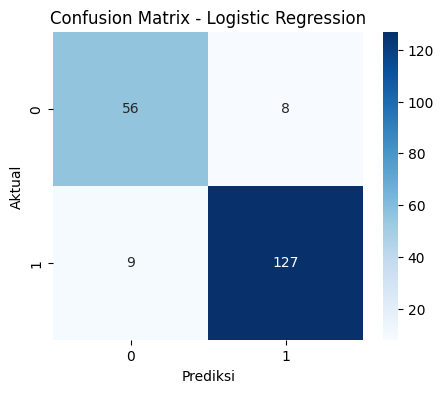

In [18]:
# 11. Visualisasi Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()